<a href="https://colab.research.google.com/github/hjfuentes/UCH_FCFM/blob/main/DMAvanzado/M01_MatEst/Laboratorio_3_Preparaci_n_y_Preprocesamiento_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

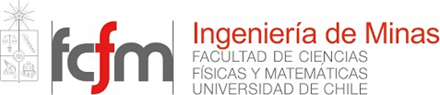

# **Laboratorio 3: Preparación y Preprocesamiento de Datos**
*Curso: Matemática y estadística fundamental para el modelamiento en minería y metalurgia*

*Diploma de Apliciones de Modelamiento Avanzado en Minería y Metalurgia*

*Profesores: Xavier Emery, Nadia Mery y Fabián Soto*



# **Highlights de este laboratorio**

En este laboratorio aprenderás:

- Entender e inspeccionar datasets reales.
- Seleccionar variables con las que se trabajará.
- Identificar tipos de datos y estructuras de tablas.
- Visualizar y trabajar elementos nulos, duplicados y outliers.
- Detectar inconsistencias y errores en los datos.
- Filtrar y transformar columnas.
- Crear nuevas variables a partir de datos existentes.
- Identificar columnas categóricas y convertir valores a enteros.
- Escalar, estandarizar y normalizar datos.
- Introducción a pipelines básicos de preprocesamiento.
- Preparación de datos para análisis estadístico y modelamiento.



# **1 - Pandas: trabajando con bases de datos**

Recordemos que, según vimos el laboratorio anterior, una librería es un **conjunto de código que ya está escrito** y puedes usar en tus programas, en vez de hacer todo desde cero.

Ya conocimos `NumPy`, `Matplotlib`, `Seaborn`  y `Scipy`. Ahora conoceremos `Pandas`, que nos simplificará el estudio estadístico de los datos.

La librería **`pandas`** proporciona estructuras de datos y funciones que permiten trabajar con datos estructurados de manera muy cómoda. Es de lo más usado en análisis de datos.

Los principales objetos ofrecidos por pandas son:

- **DataFrame**: Estructura tabular bidimensional (como una hoja de cálculo con filas y columnas).
- **Serie**: Estructura unidimensional (como una columna individual).

Ambas se basan en el array multidimensional `ndarray` de NumPy, pero ofrecen mayor flexibilidad. Esta mejora es notable al:

- **Etiquetar** filas y columnas de forma legible.
- **Gestionar valores inexistentes** (datos faltantes).
- **Agrupar datos** por una columna específica.
- **Trabajar con tipos mixtos** (números, texto, fechas en la misma tabla).

Estas limitaciones son resueltas por las estructuras de más alto nivel ofrecidas por pandas.

Para profundizar, puedes consultar la [documentación oficial de pandas](https://pandas.pydata.org/docs/user_guide/index.html#user-guide$0).

In [ ]:
# Importar la librería
import numpy as np # También la usaremos en estos ejemplos
import pandas as pd

#### **1.1 DataFrames**

Es una tabla bidimensional, que guarda datos en filas y columnas.

In [ ]:
# Crear un DataFrame

# En este ejemplo, se tienen puntos de extracción y número de paladas
plan_A = pd.DataFrame(
  data = {
    "P156_NE": [25, 22, 24, 25],
    "P176_NE": [17, 18, 18, 15],
    "P185_NE": [18, 18, 19, 16],
    "P189_NE": [18, 19, 17, 16],
    "P348_NW": [22, 23, 22, 21],
    "P367_NW": [20, 21, 23, 20],
    "P317_NW": [24, 23, 23, 21],
    "P319_NW": [60, 23, 23, 21],
    "P342_NW": [22, 0, 23, np.nan]
  },
  index = ["Lunes", "Martes", "Miercoles", "Jueves"]
)

plan_A # Mostrar en pantalla

,P156_NE,P176_NE,P185_NE,P189_NE,P348_NW,P367_NW,P317_NW,P319_NW,P342_NW
Lunes,25,17,18,18,22,20,24,60,22.0
Martes,22,18,18,19,23,21,23,23,0.0
Miercoles,24,18,19,17,22,23,23,23,23.0
Jueves,25,15,16,16,21,20,21,21,NaN


##### Algunas operaciones con DataFrames

`transpose`: intercambiar filas por columnas.








In [ ]:
# Transponer un DataFrame

plan_A_transpose = plan_A.copy() # Primero creamos una copia
plan_A_transpose = plan_A_transpose.transpose() # Luego transponemos la copia

plan_A_transpose # Mostrar en pantalla

,Lunes,Martes,Miercoles,Jueves
P156_NE,25.0,22.0,24.0,25.0
P176_NE,17.0,18.0,18.0,15.0
P185_NE,18.0,18.0,19.0,16.0
P189_NE,18.0,19.0,17.0,16.0
P348_NW,22.0,23.0,22.0,21.0
P367_NW,20.0,21.0,23.0,20.0
P317_NW,24.0,23.0,23.0,21.0
P319_NW,60.0,23.0,23.0,21.0
P342_NW,22.0,0.0,23.0,NaN


In [ ]:
# Asignar un nombre al índice
plan_A_transpose.index.name = "Punto Extr."

plan_A_transpose

,Lunes,Martes,Miercoles,Jueves
Punto Extr.,,,,
P156_NE,25.0,22.0,24.0,25.0
P176_NE,17.0,18.0,18.0,15.0
P185_NE,18.0,18.0,19.0,16.0
P189_NE,18.0,19.0,17.0,16.0
P348_NW,22.0,23.0,22.0,21.0
P367_NW,20.0,21.0,23.0,20.0
P317_NW,24.0,23.0,23.0,21.0
P319_NW,60.0,23.0,23.0,21.0
P342_NW,22.0,0.0,23.0,NaN


In [ ]:
# Modificar datos con operación vectorizada

# En este ejemplo se multiplican todos los valores de Lunes por 0.9 y se redondea
plan_A_transpose['Lunes'] = np.round(plan_A_transpose['Lunes']*0.9, 0)

plan_A_transpose

,Lunes,Martes,Miercoles,Jueves
Punto Extr.,,,,
P156_NE,22.0,22.0,24.0,25.0
P176_NE,15.0,18.0,18.0,15.0
P185_NE,16.0,18.0,19.0,16.0
P189_NE,16.0,19.0,17.0,16.0
P348_NW,20.0,23.0,22.0,21.0
P367_NW,18.0,21.0,23.0,20.0
P317_NW,22.0,23.0,23.0,21.0
P319_NW,54.0,23.0,23.0,21.0
P342_NW,20.0,0.0,23.0,NaN


`to_numpy()`: Convertir valores numéricos en un array de Numpy

In [ ]:
print(plan_A.to_numpy()) # convertir valores numericos en numpy array

[[25. 17. 18. 18. 22. 20. 24. 60. 22.]
 [22. 18. 18. 19. 23. 21. 23. 23.  0.]
 [24. 18. 19. 17. 22. 23. 23. 23. 23.]
 [25. 15. 16. 16. 21. 20. 21. 21. nan]]


In [ ]:
# Agregar columna con suma

# Crea una nueva columna que suma los valores de cada fila
# axis=1 suma horizontalmente (a lo largo de las columnas)
plan_A_transpose["Total"] = plan_A_transpose.sum(axis = 1)

plan_A_transpose

,Lunes,Martes,Miercoles,Jueves,Total
Punto Extr.,,,,,
P156_NE,22.0,22.0,24.0,25.0,93.0
P176_NE,15.0,18.0,18.0,15.0,66.0
P185_NE,16.0,18.0,19.0,16.0,69.0
P189_NE,16.0,19.0,17.0,16.0,68.0
P348_NW,20.0,23.0,22.0,21.0,86.0
P367_NW,18.0,21.0,23.0,20.0,82.0
P317_NW,22.0,23.0,23.0,21.0,89.0
P319_NW,54.0,23.0,23.0,21.0,121.0
P342_NW,20.0,0.0,23.0,NaN,43.0


In [ ]:
# Agregar columna con valores categóricos

# Crea una nueva columna con valores de texto ("Si" / "No")
#   Esta lista debe tener el mismo número de elementos que la fila
plan_A_transpose["Barro"] = ["No", "No", "No", "Si", "No", "Si", "Si", "No", "Si"]

plan_A_transpose

,Lunes,Martes,Miercoles,Jueves,Total,Barro
Punto Extr.,,,,,,
P156_NE,22.0,22.0,24.0,25.0,93.0,No
P176_NE,15.0,18.0,18.0,15.0,66.0,No
P185_NE,16.0,18.0,19.0,16.0,69.0,No
P189_NE,16.0,19.0,17.0,16.0,68.0,Si
P348_NW,20.0,23.0,22.0,21.0,86.0,No
P367_NW,18.0,21.0,23.0,20.0,82.0,Si
P317_NW,22.0,23.0,23.0,21.0,89.0,Si
P319_NW,54.0,23.0,23.0,21.0,121.0,No
P342_NW,20.0,0.0,23.0,NaN,43.0,Si


In [ ]:
# Acceder a un valor individual, indicando su columna y fila
plan_A_transpose["Lunes"]["P176_NE"]

np.float64(15.0)

In [ ]:
# Cantidad de valores iguales a algo en una columna
columna_barro = plan_A_transpose["Barro"]
coincidencias_col = (columna_barro == "Si").sum()
print(f"Celdas con valor 'Si' en columna Barro: {coincidencias_col}")

Celdas con valor 'Si' en columna Barro: 4


In [ ]:
# Cantidad de valores distintos a algo en una columna
no_coincidencias = (columna_barro != 1).sum()
print(f"Celdas que NO tienen valor 1 en columna barro: {no_coincidencias}")

Celdas que NO tienen valor 1 en columna barro: 9


In [ ]:
# Seleccionar un rango de filas
plan_A_transpose.loc["P176_NE":"P189_NE", :]

,Lunes,Martes,Miercoles,Jueves,Total,Barro
Punto Extr.,,,,,,
P176_NE,15.0,18.0,18.0,15.0,66.0,No
P185_NE,16.0,18.0,19.0,16.0,69.0,No
P189_NE,16.0,19.0,17.0,16.0,68.0,Si


In [ ]:
# Seleccionar múltiples filas pero de una columna específica
plan_A_transpose.loc["P176_NE":"P189_NE", "Barro"]

,Barro
Punto Extr.,
P176_NE,No
P185_NE,No
P189_NE,Si


In [ ]:
# Seleccionar desde una fila hasta el final
plan_A_transpose.loc["P348_NW":, "Total"]

,Total
Punto Extr.,
P348_NW,86.0
P367_NW,82.0
P317_NW,89.0
P319_NW,121.0
P342_NW,43.0


In [ ]:
# Seleccionar filas por posición (usar números en vez de etiquetas)
plan_A_transpose.iloc[1:4, :]

,Lunes,Martes,Miercoles,Jueves,Total,Barro
Punto Extr.,,,,,,
P176_NE,15.0,18.0,18.0,15.0,66.0,No
P185_NE,16.0,18.0,19.0,16.0,69.0,No
P189_NE,16.0,19.0,17.0,16.0,68.0,Si


In [ ]:
# Seleccionar desde la fila 4 hasta el final, sólo la columna en posición 4
plan_A_transpose.iloc[4:, 4]

,Total
Punto Extr.,
P348_NW,86.0
P367_NW,82.0
P317_NW,89.0
P319_NW,121.0
P342_NW,43.0


######Informaciones generales de un dataframe

`.shape`: Obtener dimensiones de un DataFrame

In [ ]:
print(plan_A_transpose.shape) # Cantidad de filas, cantidad de columnas

(9, 6)


`.head()`: Inspeccionar primeras filas

In [ ]:
#   Suele ser útil cuando uno quiere hacerse una idea del formato del DataFrame
plan_A_transpose.head(3) # El parámetro es es número de filas a mostrar, en este caso 3

,Lunes,Martes,Miercoles,Jueves,Total,Barro
Punto Extr.,,,,,,
P156_NE,22.0,22.0,24.0,25.0,93.0,No
P176_NE,15.0,18.0,18.0,15.0,66.0,No
P185_NE,16.0,18.0,19.0,16.0,69.0,No


`.tail()`: Inspeccionar últimas filas

In [ ]:
plan_A_transpose.tail(2) # El parámetro es es número de filas a mostrar, en este caso 2

,Lunes,Martes,Miercoles,Jueves,Total,Barro
Punto Extr.,,,,,,
P319_NW,54.0,23.0,23.0,21.0,121.0,No
P342_NW,20.0,0.0,23.0,NaN,43.0,Si


`.info()`: Información general de un DataFrame

In [ ]:
# Permite obtener un resumen estructural del DataFrame, incluyendo columnas, tipos de datos, cantidad de valores no nulos y uso de memoria.
plan_A_transpose.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9 entries, P156_NE to P342_NW
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Lunes      9 non-null      float64
 1   Martes     9 non-null      float64
 2   Miercoles  9 non-null      float64
 3   Jueves     8 non-null      float64
 4   Total      9 non-null      float64
 5   Barro      9 non-null      object 
dtypes: float64(5), object(1)
memory usage: 804.0+ bytes


###### Más operaciones en DataFrames

In [ ]:
# Reemplazar valores específicos

# Remplazar los valores 23 por 1, de manera inmediata
plan_A_transpose.replace(23., 1., inplace = True)

In [ ]:
# Pasar una variable categórica a numérica codificando sus valores

# Codificar la variable Barro para que sea un variable numerica
#   En este caso, la codificación es: "Si" → 1, "No" → 0.
plan_A_transpose["Barro"] = plan_A_transpose["Barro"].replace(["Si", "No"], [1, 0])

plan_A_transpose

/tmp/ipykernel_20502/34228303.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plan_A_transpose["Barro"] = plan_A_transpose["Barro"].replace(["Si", "No"], [1, 0])


,Lunes,Martes,Miercoles,Jueves,Total,Barro
Punto Extr.,,,,,,
P156_NE,22.0,22.0,24.0,25.0,93.0,0
P176_NE,15.0,18.0,18.0,15.0,66.0,0
P185_NE,16.0,18.0,19.0,16.0,69.0,0
P189_NE,16.0,19.0,17.0,16.0,68.0,1
P348_NW,20.0,1.0,22.0,21.0,86.0,0
P367_NW,18.0,21.0,1.0,20.0,82.0,1
P317_NW,22.0,1.0,1.0,21.0,89.0,1
P319_NW,54.0,1.0,1.0,21.0,121.0,0
P342_NW,20.0,0.0,1.0,NaN,43.0,1


In [ ]:
# Filtrado condicional

# Seleccionar sólo las filas donde el total es mayor a 70
#   y menor o igual a 90
plan_A_transpose.loc[(plan_A_transpose.Total > 70) & (plan_A_transpose['Total'] <= 90)]

,Lunes,Martes,Miercoles,Jueves,Total,Barro
Punto Extr.,,,,,,
P348_NW,20.0,1.0,22.0,21.0,86.0,0
P367_NW,18.0,21.0,1.0,20.0,82.0,1
P317_NW,22.0,1.0,1.0,21.0,89.0,1


###### Crear segundo DataFrame

In [ ]:
# Crear otro DataFrame similar, con otros datos
plan_B = pd.DataFrame(
  data = {
    "P458_SE": [15, 18, 14, 15],
    "P476_SE": [17, 18, 18, 15],
    "P485_SE": [18, 18, 19, 16],
    "P559_SE": [18, 19, 17, 16],
    "P685_SW": [22, 23, 22, 21],
    "P667_SW": [20, 21, 23, 20],
    "P617_SW": [24, 23, 23, 21],
    "P619_SW": [60, 23, 23, 21],
    "P348_SW": [22, 23, 22, 21]
  },
  index = ["Lunes", "Martes", "Miercoles", "Jueves"]
)

plan_B # Mostrarlo en pantalla

,P458_SE,P476_SE,P485_SE,P559_SE,P685_SW,P667_SW,P617_SW,P619_SW,P348_SW
Lunes,15,17,18,18,22,20,24,60,22
Martes,18,18,18,19,23,21,23,23,23
Miercoles,14,18,19,17,22,23,23,23,22
Jueves,15,15,16,16,21,20,21,21,21


In [ ]:
# Procesar segundo dataframe

plan_B = plan_B.transpose() # Transponer (cambiar filas por columnas)
plan_B["Total"] = plan_B.sum(axis=1) # Añadir columna de suma total
plan_B["Barro"] = [1, 1, 0, 1, 0, 0, 1, 1, 0] # Añadir columna de Barro

plan_B # Mostrar en pantalla

,Lunes,Martes,Miercoles,Jueves,Total,Barro
P458_SE,15,18,14,15,62,1
P476_SE,17,18,18,15,68,1
P485_SE,18,18,19,16,71,0
P559_SE,18,19,17,16,70,1
P685_SW,22,23,22,21,88,0
P667_SW,20,21,23,20,84,0
P617_SW,24,23,23,21,91,1
P619_SW,60,23,23,21,127,1
P348_SW,22,23,22,21,88,0


`concat`: concatenar dos DataFrames

In [ ]:
#   Es decir, unirlos y quedarnos con un solo DataFrame, donde
#   plan_B queda debajo de plan_A
plan_A = pd.concat([plan_A_transpose, plan_B])

plan_A # Mostrar en pantalla

,Lunes,Martes,Miercoles,Jueves,Total,Barro
P156_NE,22.0,22.0,24.0,25.0,93.0,0
P176_NE,15.0,18.0,18.0,15.0,66.0,0
P185_NE,16.0,18.0,19.0,16.0,69.0,0
P189_NE,16.0,19.0,17.0,16.0,68.0,1
P348_NW,20.0,1.0,22.0,21.0,86.0,0
P367_NW,18.0,21.0,1.0,20.0,82.0,1
P317_NW,22.0,1.0,1.0,21.0,89.0,1
P319_NW,54.0,1.0,1.0,21.0,121.0,0
P342_NW,20.0,0.0,1.0,NaN,43.0,1
P458_SE,15.0,18.0,14.0,15.0,62.0,1


`join`: Unir DataFrames usando sus índices.

In [ ]:
# Unir plan_A_transpose y plan_B usando sus índices
df_join = plan_A_transpose.join(
    plan_B,
    lsuffix="_A",
    rsuffix="_B"
)

# Mostrar resultado
df_join

,Lunes_A,Martes_A,Miercoles_A,Jueves_A,Total_A,Barro_A,Lunes_B,Martes_B,Miercoles_B,Jueves_B,Total_B,Barro_B
Punto Extr.,,,,,,,,,,,,
P156_NE,22.0,22.0,24.0,25.0,93.0,0,NaN,NaN,NaN,NaN,NaN,NaN
P176_NE,15.0,18.0,18.0,15.0,66.0,0,NaN,NaN,NaN,NaN,NaN,NaN
P185_NE,16.0,18.0,19.0,16.0,69.0,0,NaN,NaN,NaN,NaN,NaN,NaN
P189_NE,16.0,19.0,17.0,16.0,68.0,1,NaN,NaN,NaN,NaN,NaN,NaN
P348_NW,20.0,1.0,22.0,21.0,86.0,0,NaN,NaN,NaN,NaN,NaN,NaN
P367_NW,18.0,21.0,1.0,20.0,82.0,1,NaN,NaN,NaN,NaN,NaN,NaN
P317_NW,22.0,1.0,1.0,21.0,89.0,1,NaN,NaN,NaN,NaN,NaN,NaN
P319_NW,54.0,1.0,1.0,21.0,121.0,0,NaN,NaN,NaN,NaN,NaN,NaN
P342_NW,20.0,0.0,1.0,NaN,43.0,1,NaN,NaN,NaN,NaN,NaN,NaN


`where()`: Mantener valores que cumplen una condición y reemplazar los demás por otro valor.


In [ ]:
# Mantener valores que cumplen una condición
# y reemplazar los demás por NaN.

# Mantener sólo los puntos cuyo Total sea mayor a 80
plan_A_where = plan_A_transpose.where(
    plan_A_transpose["Total"] > 80
)

# Mostrar resultado
plan_A_where

,Lunes,Martes,Miercoles,Jueves,Total,Barro
Punto Extr.,,,,,,
P156_NE,22.0,22.0,24.0,25.0,93.0,0.0
P176_NE,NaN,NaN,NaN,NaN,NaN,NaN
P185_NE,NaN,NaN,NaN,NaN,NaN,NaN
P189_NE,NaN,NaN,NaN,NaN,NaN,NaN
P348_NW,20.0,1.0,22.0,21.0,86.0,0.0
P367_NW,18.0,21.0,1.0,20.0,82.0,1.0
P317_NW,22.0,1.0,1.0,21.0,89.0,1.0
P319_NW,54.0,1.0,1.0,21.0,121.0,0.0
P342_NW,NaN,NaN,NaN,NaN,NaN,NaN


`sort_values()`: Ordenar un DataFrame según los valores de una columna.

In [ ]:
# Ordenar puntos según el Total, de mayor a menor
plan_A_sorted = plan_A_transpose.sort_values(
    by="Total",
    ascending=False
)

# Mostrar resultado
plan_A_sorted

,Lunes,Martes,Miercoles,Jueves,Total,Barro
Punto Extr.,,,,,,
P319_NW,54.0,1.0,1.0,21.0,121.0,0
P156_NE,22.0,22.0,24.0,25.0,93.0,0
P317_NW,22.0,1.0,1.0,21.0,89.0,1
P348_NW,20.0,1.0,22.0,21.0,86.0,0
P367_NW,18.0,21.0,1.0,20.0,82.0,1
P185_NE,16.0,18.0,19.0,16.0,69.0,0
P189_NE,16.0,19.0,17.0,16.0,68.0,1
P176_NE,15.0,18.0,18.0,15.0,66.0,0
P342_NW,20.0,0.0,1.0,NaN,43.0,1


`rank()`: Asignar un ranking según los valores de una columna.


In [ ]:
# Crear una nueva columna con el ranking del Total
# El valor más alto recibe ranking 1
plan_A_transpose["Ranking"] = plan_A_transpose["Total"].rank(
    ascending=False
)

# Mostrar resultado
plan_A_transpose

,Lunes,Martes,Miercoles,Jueves,Total,Barro,Ranking
Punto Extr.,,,,,,,
P156_NE,22.0,22.0,24.0,25.0,93.0,0,2.0
P176_NE,15.0,18.0,18.0,15.0,66.0,0,8.0
P185_NE,16.0,18.0,19.0,16.0,69.0,0,6.0
P189_NE,16.0,19.0,17.0,16.0,68.0,1,7.0
P348_NW,20.0,1.0,22.0,21.0,86.0,0,4.0
P367_NW,18.0,21.0,1.0,20.0,82.0,1,5.0
P317_NW,22.0,1.0,1.0,21.0,89.0,1,3.0
P319_NW,54.0,1.0,1.0,21.0,121.0,0,1.0
P342_NW,20.0,0.0,1.0,NaN,43.0,1,9.0


# **2 -  Importando bases de datos**

#### **Lectura y guardado de archivos**

Pandas nos entrega un conjunto de funciones con las que podemos **leer archivos** y almacenar el contenido en un objeto pandas. Estas funciones se conocen como *readers*.

También tenemos funciones de escritura conocidas como *writers*, con los que podemos **escribir o escribir archivos**.

Aquí una tabla resumen con las funciones que existen para los tipos de archivo más frecuentes:

| Formato | Tipo | Reader | Writer | Uso común |
| :--- | :---: | :---: | :---: | :--- |
| CSV | texto | `read_csv` | `to_csv` | Intercambio general de datos |
| JSON | texto | `read_json` | `to_json` | APIs y aplicaciones web |
| HTML | texto | `read_html` | `to_html` | Tablas en páginas web |
| MS Excel | binario | `read_excel` | `to_excel` | Reportes y hojas de cálculo |
| HDF5 | binario | `read_hdf` | `to_hdf` | Grandes volúmenes de datos numéricos |
| Parquet | binario | `read_parquet` | `to_parquet` | Big Data y análisis eficiente |
| Stata | binario | `read_stata` | `to_stata` | Estadística académica |
| SAS | binario | `read_sas` | — | Estadística empresarial |
| SPSS | binario | `read_spss` | — | Estadística en ciencias sociales |
| Pickle | binario | `read_pickle` | `to_pickle` | Guardar objetos Python |
| SQL | base de datos | `read_sql` | `to_sql` | Bases de datos relacionales |

Recuerda que puedes visitar la documentación de pandas para ver el detalle de cada función.

##### **Leer archivos `.csv`**

De los recién vistos, un caso interesante es la lectura de archivos `.csv` (*Comma-Separated Values*). Los archivos `.csv` son básicamente un archivo de texto plano donde los datos están separados por comas, formando una tabla donde cada línea representa una fila y cada coma separa una columna.

Por ejemplo, así:

```csv
punto,Lunes,Martes,Miercoles,Jueves
P156_NE,25,22,24,25
P176_NE,17,18,18,15
P185_NE,18,18,19,1
```

La primera fila suele ser el **encabezado** con los nombres de las columnas, y las filas siguientes contienen los datos.

Para las siguientes partes deben subir este archivo a su Google Drive:
- yacimiento_ferrifero.csv

Luego, probablemente necesiten editar el siguiente bloque de código para abrir dichos archivos aquí:

In [5]:
from google.colab import drive # Importar librería de Google Drive
import pandas as pd

drive.mount('/content/drive') # Montar Google Drive para poder usarlo en este Colab

Mounted at /content/drive


In [22]:
# Indicar qué la ruta del archivo a cargar
#   Modificar la ruta en caso de ser necesario,dependiendo
#   de dónde guardaron el archivo yacimiento_ferrifero

dh_df = pd.read_csv("/content/sample_data/yacimiento_ferrifero.csv", delimiter = ",")
#dh_df = pd.read_csv("/content/sample_data/yacimiento_ferrifero.csv"
# dh_df = pd.read_csv("yacimiento_ferrifero.csv", delimiter = ",")

Las variables contenidas en esta base de datos corresponden a

|Nombre|Variable|
|------|--------|
|Easting|Coordenada este|
|Northing|Coordenada norte|
|Elevation|Coordenada elevación|
|Fe|Contenido de Fierro (%)|
|Si|Contenido de Sílice (%)|
|P|Contenido de Fosforo (%)|
|Mn|Contenido de Manganeso (%)|
|Pf|Pérdida de fuego - % en masa perdido por elemento sometido a una T° específica|
|G1|Fracción granulométrica con tamaño particula >6.3 mm (%)|
|Rocktype|Tipo de roca |

Los valores NaN son valores sin información

In [23]:
dh_df # Muestra el DataFrame completo

,Easting,Northing,Elevation,Fe,Si,P,Al,Mn,Pf,g1,Rocktype
0,-7400.22,1496.58,1457.62,46.478,31.620,0.017,1.139,0.010,0.698,38.160,7
1,-7400.22,1496.58,1450.37,40.578,40.838,0.028,0.711,0.010,0.346,78.200,7
2,-7400.22,1496.58,1427.72,40.488,40.655,0.012,0.914,0.010,0.482,69.690,6
3,-7400.22,1496.58,1421.62,40.488,40.655,0.012,0.914,0.010,0.482,69.690,6
4,-7400.22,1496.58,1415.52,43.969,35.776,0.017,0.854,0.010,0.432,40.230,7
...,...,...,...,...,...,...,...,...,...,...,...
4471,-5532.36,1343.19,1411.63,52.866,13.721,0.118,3.115,0.073,6.231,30.528,9
4472,-5532.36,1343.19,1405.50,49.723,22.790,0.120,1.086,0.170,3.627,26.393,4
4473,-5532.36,1343.19,1397.30,49.723,22.790,0.120,1.086,0.170,3.627,26.393,4
4474,-5532.36,1343.19,1389.10,45.793,28.937,0.103,1.289,0.076,2.998,14.767,7


In [24]:
dh_df.info() # Muestra un resumen del DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4476 entries, 0 to 4475
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Easting    4476 non-null   float64
 1   Northing   4476 non-null   float64
 2   Elevation  4476 non-null   float64
 3   Fe         4476 non-null   float64
 4   Si         4476 non-null   float64
 5   P          4476 non-null   float64
 6   Al         4476 non-null   float64
 7   Mn         4476 non-null   float64
 8   Pf         4476 non-null   float64
 9   g1         4476 non-null   float64
 10  Rocktype   4476 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 384.8 KB


# **3 -  Calidad de datos**

En problemas reales de minería y metalurgia, los datos rara vez están perfectamente limpios.

Es común encontrar:

- valores faltantes
- filas duplicadas
- errores de digitación
- valores imposibles
- mediciones extremas
- inconsistencias entre variables.

Antes de realizar análisis estadístico o modelamiento, es fundamental inspeccionar y preparar correctamente los datos.

###### **3.1 - Inspección general**

In [11]:
dh_df.head()

,Easting,Northing,Elevation,Fe,Si,P,Al,Mn,Pf,g1,Rocktype
0,-7400.22,1496.58,1457.62,46.478,31.620,0.017,1.139,0.01,0.698,38.16,7
1,-7400.22,1496.58,1450.37,40.578,40.838,0.028,0.711,0.01,0.346,78.20,7
2,-7400.22,1496.58,1427.72,40.488,40.655,0.012,0.914,0.01,0.482,69.69,6
3,-7400.22,1496.58,1421.62,40.488,40.655,0.012,0.914,0.01,0.482,69.69,6
4,-7400.22,1496.58,1415.52,43.969,35.776,0.017,0.854,0.01,0.432,40.23,7


In [25]:
dh_df.shape

(4476, 11)

In [13]:
dh_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4465 entries, 0 to 4464
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Easting    4465 non-null   float64
 1   Northing   4465 non-null   float64
 2   Elevation  4465 non-null   float64
 3   Fe         4465 non-null   float64
 4   Si         4465 non-null   float64
 5   P          4465 non-null   float64
 6   Al         4465 non-null   float64
 7   Mn         4465 non-null   float64
 8   Pf         4465 non-null   float64
 9   g1         4465 non-null   float64
 10  Rocktype   4465 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 383.8 KB


`describe()` genera un resumen estadístico de los datos numéricos de un DataFrame

In [26]:
dh_df.describe()

,Easting,Northing,Elevation,Fe,Si,P,Al,Mn,Pf,g1,Rocktype
count,4476.000000,4476.000000,4476.000000,4476.000000,4476.000000,4476.000000,4476.000000,4476.000000,4476.000000,4476.000000,4476.000000
mean,-6416.530503,1389.523356,1322.071416,51.766135,21.804994,0.054745,1.308892,0.299824,2.246704,33.148303,2.497542
std,540.142524,190.921949,85.933223,11.704996,17.422758,0.041058,1.287799,1.390089,2.014037,23.501972,18.276553
min,-7501.240000,902.280000,1025.580000,9.916000,0.216000,0.007000,0.100000,0.008000,0.057000,0.116000,-99.000000
25%,-6800.020000,1259.070000,1276.357500,42.415750,4.310000,0.027000,0.458750,0.014000,0.818000,14.771500,3.000000
50%,-6356.455000,1384.405000,1335.315000,52.920000,20.299500,0.044000,0.912000,0.030000,1.582000,26.979500,7.000000
75%,-6000.000000,1505.977500,1379.432500,62.253000,36.486500,0.071000,1.714000,0.085000,2.922500,47.430500,7.000000
max,-5386.290000,1937.520000,1517.900000,169.701000,77.045000,0.530000,12.599000,32.057000,13.835000,98.184000,10.000000


In [27]:
# Calcula estadísticas descriptivas usando percentiles personalizados
# en lugar de los percentiles por defecto (25%, 50%, 75%)
dh_df.describe(percentiles=[0.05, 0.5, 0.95])

,Easting,Northing,Elevation,Fe,Si,P,Al,Mn,Pf,g1,Rocktype
count,4476.000000,4476.000000,4476.000000,4476.000000,4476.000000,4476.000000,4476.000000,4476.000000,4476.000000,4476.000000,4476.000000
mean,-6416.530503,1389.523356,1322.071416,51.766135,21.804994,0.054745,1.308892,0.299824,2.246704,33.148303,2.497542
std,540.142524,190.921949,85.933223,11.704996,17.422758,0.041058,1.287799,1.390089,2.014037,23.501972,18.276553
min,-7501.240000,902.280000,1025.580000,9.916000,0.216000,0.007000,0.100000,0.008000,0.057000,0.116000,-99.000000
5%,-7400.220000,1079.325000,1149.792500,32.260500,0.695000,0.014000,0.186000,0.010000,0.337000,4.863000,1.000000
50%,-6356.455000,1384.405000,1335.315000,52.920000,20.299500,0.044000,0.912000,0.030000,1.582000,26.979500,7.000000
95%,-5500.392500,1734.030000,1445.765000,67.528000,50.895000,0.128000,3.807500,1.270500,6.474000,81.320500,9.000000
max,-5386.290000,1937.520000,1517.900000,169.701000,77.045000,0.530000,12.599000,32.057000,13.835000,98.184000,10.000000


###### **3.2 - Valores faltantes (missing values)**




In [28]:
# Detectar valores faltantes por columna
dh_df.isnull().sum()

,0
Easting,0
Northing,0
Elevation,0
Fe,0
Si,0
P,0
Al,0
Mn,0
Pf,0
g1,0


In [29]:
# Mostrar sólo columnas con valores faltantes
dh_df.isnull().sum()[dh_df.isnull().sum() > 0]

,0


**¿Qué hacer si existen datos faltantes?**

Los datos faltantes pueden afectar el análisis y la calidad de los resultados, por lo que es importante identificarlos y tratarlos adecuadamente.

Algunas estrategias comunes son:

- Eliminar registros con datos faltantes
- Ignorar valores faltantes en ciertos análisis
- Imputar valores utilizando promedios, medianas u otros métodos

La estrategia más adecuada dependerá del contexto, la cantidad de datos faltantes y el objetivo del análisis.

In [30]:
# Creamos una copia
dh_df_notNulls = dh_df.copy()

In [ ]:
# Opción 1: Imputar los valores nulos de la columna con la mediana de los valores de su columna
#dh_df = dh_df.fillna(dh_df.median())

In [31]:
# Opción 2: eliminar filas con valores faltantes
dh_df = dh_df.dropna()

In [32]:
# Confirmar que no hay NaN
dh_df.isnull().sum()

,0
Easting,0
Northing,0
Elevation,0
Fe,0
Si,0
P,0
Al,0
Mn,0
Pf,0
g1,0


###### **3.3 - Duplicados**

In [33]:
# Identifica las filas duplicadas y las guarda en dup_rows
dup_rows = dh_df[dh_df.duplicated()]

dup_rows # Mostrar en pantalla

,Easting,Northing,Elevation,Fe,Si,P,Al,Mn,Pf,g1,Rocktype
7,-7400.22,1496.58,1415.52,43.969,35.776,0.017,0.854,0.010,0.432,40.23,7
8,-7400.22,1496.58,1407.12,43.969,35.776,0.017,0.854,0.010,0.432,40.23,7
9,-7400.22,1496.58,1415.52,43.969,35.776,0.017,0.854,0.010,0.432,40.23,7
10,-7400.22,1496.58,1407.12,43.969,35.776,0.017,0.854,0.010,0.432,40.23,7
11,-7400.22,1496.58,1400.92,31.584,53.616,0.014,0.763,0.010,0.400,66.08,7
12,-7400.22,1496.58,1415.52,43.969,35.776,0.017,0.854,0.010,0.432,40.23,7
13,-7400.22,1496.58,1407.12,43.969,35.776,0.017,0.854,0.010,0.432,40.23,7
14,-7400.22,1496.58,1400.92,31.584,53.616,0.014,0.763,0.010,0.400,66.08,7
16,-7401.00,1814.63,1471.68,64.192,0.755,0.111,2.046,0.083,4.801,66.64,10
17,-7401.00,1814.63,1471.68,64.192,0.755,0.111,2.046,0.083,4.801,66.64,10


In [38]:
filas_identicas = dh_df[dh_df.duplicated(keep=False)]
filas_identicas

,Easting,Northing,Elevation,Fe,Si,P,Al,Mn,Pf,g1,Rocktype
4,-7400.22,1496.58,1415.52,43.969,35.776,0.017,0.854,0.010,0.432,40.23,7
5,-7400.22,1496.58,1407.12,43.969,35.776,0.017,0.854,0.010,0.432,40.23,7
6,-7400.22,1496.58,1400.92,31.584,53.616,0.014,0.763,0.010,0.400,66.08,7
7,-7400.22,1496.58,1415.52,43.969,35.776,0.017,0.854,0.010,0.432,40.23,7
8,-7400.22,1496.58,1407.12,43.969,35.776,0.017,0.854,0.010,0.432,40.23,7
9,-7400.22,1496.58,1415.52,43.969,35.776,0.017,0.854,0.010,0.432,40.23,7
10,-7400.22,1496.58,1407.12,43.969,35.776,0.017,0.854,0.010,0.432,40.23,7
11,-7400.22,1496.58,1400.92,31.584,53.616,0.014,0.763,0.010,0.400,66.08,7
12,-7400.22,1496.58,1415.52,43.969,35.776,0.017,0.854,0.010,0.432,40.23,7
13,-7400.22,1496.58,1407.12,43.969,35.776,0.017,0.854,0.010,0.432,40.23,7


In [34]:
# Obtiene los índices de las filas duplicadas como lista
dup_rows.index.tolist()

[7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18]

In [ ]:
# Elimina las filas duplicadas del DataFrame original
# axis=0 indica que se eliminan filas (no columnas)
dh_df = dh_df.drop(dup_rows.index.tolist(), axis=0)

In [ ]:
# Vuelve a verificar si quedan filas duplicadas tras la eliminación
dup_rows = dh_df[dh_df.duplicated()]

dup_rows # Mostrar en pantalla

,Easting,Northing,Elevation,Fe,Si,P,Al,Mn,Pf,g1,Rocktype


###### **3.4 - Valores inconsistentes**

En contextos mineros y metalúrgicos se pueden observar algunas de las siguientes inconsistencias. Notar que pueden existir otras según la naturaleza de la variable en estudio.

| Variable      | Problema                  |
|---------------|----------------------------|
| Recuperación  | Valores negativos o mayores a 100%      |
| Ley           | Valores negativos o mayores a 100%         |
| Equipo        | Typos o nombres incorrectos |
| Fecha         | Formato inválido o inconsistente |
| Turno         | Categorías inconsistentes  |
| Tiempos         | Valores negativos o superiores a un turno |

Revisión de typos en variables categóricas.
En este caso están codificadas como números, no como códigos.

In [ ]:
# Revisar las categorías presentes en variables de texto para ver typos o nombres incorrectos

print(dh_df["Rocktype"].unique())

[ 7.  6. 10.  4.  9.  3.  1.  8.  2.  5.]


Leyes inferiores a 0%

In [ ]:
# Contar cuántos valores negativos existen en las leyes y tipo de roca

# Variables donde valores negativos NO son válidos
variables_validar = ["Fe", "Si", "P", "Al", "Mn", "Pf", "g1", "Rocktype"]

# Contar negativos
negative_counts = (dh_df[variables_validar] < 0).sum()

print("Cantidad de valores negativos:")
print(negative_counts)

Cantidad de valores negativos:
Fe          0
Si          0
P           0
Al          1
Mn          0
Pf          0
g1          0
Rocktype    0
dtype: int64


In [ ]:
# Mostrar filas con valores negativos
dh_df.loc[(dh_df[variables_validar] < 0).any(axis=1)]

,Easting,Northing,Elevation,Fe,Si,P,Al,Mn,Pf,g1,Rocktype
2935,-5999.88,1352.48,1285.31,51.765,23.696,0.033,-0.299,0.01,0.622,17.164,8.0


In [ ]:
# Eliminar filas con valores negativos
dh_df = dh_df.loc[~(dh_df[variables_validar] < 0).any(axis=1)]

**Notar que:** el valor negativo de las coordenadas no corresponde a un error, sino que se debe al sistema de coordenadas local utilizado. Por eso se excluyen del análisis

Leyes superiores a 100%

In [ ]:
# Contar valores mayores a 100
high_counts = (dh_df[variables_validar] > 100).sum()

print("Cantidad de valores mayores a 100%:")
print(high_counts)

Cantidad de valores mayores a 100%:
Fe          1
Si          0
P           0
Al          0
Mn          0
Pf          0
g1          0
Rocktype    0
dtype: int64


In [ ]:
# Mostrar filas con valores mayores a 100%
dh_df.loc[(dh_df[variables_validar] > 100).any(axis=1)]

,Easting,Northing,Elevation,Fe,Si,P,Al,Mn,Pf,g1,Rocktype
1884,-5849.02,1648.72,1352.65,100.463,5.596,0.077,3.115,0.063,4.015,10.452,4.0


In [ ]:
# Eliminar filas con valores mayores a 100%
dh_df = dh_df.loc[~(dh_df[variables_validar] > 100).any(axis=1)]

Las leyes minerales representan proporciones o porcentajes, por lo que valores superiores a 100% son físicamente inconsistentes y deben revisarse. No neceseriamente se deben eliminar, todo dependerá de las características de la base de datos.

###### **3.5 -  Outliers**

Los outliers son valores extremadamente alejados del comportamiento normal de los datos.

Pueden representar:

- errores
- eventos inusuales
- o condiciones operacionales especiales.

Pueden ser determinados con herramientas como:
- Boxplot
- z-score
- IQR
- Test de Grubss o Chauvenet (requieren distribución Gaussiana de los datos)

In [ ]:
import matplotlib.pyplot as plt

**3.5.1 Boxplot**

Los `boxplots` permiten identificar visualmente la dispersión de los datos y posibles valores atípicos (outliers).

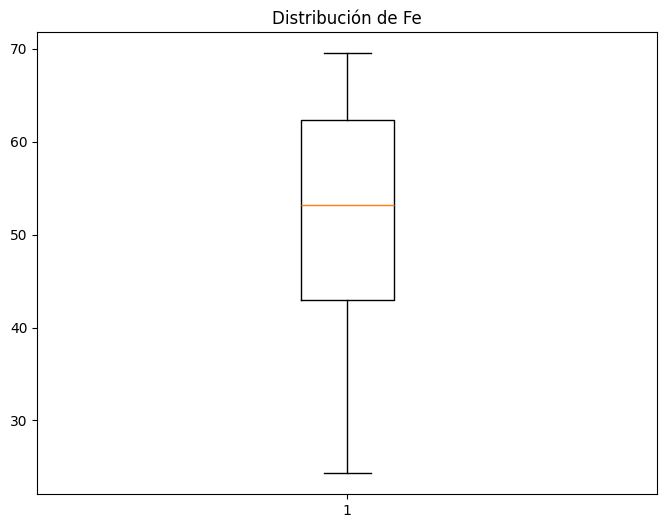

In [ ]:
# boxplot de ley de Fe
# Este ejercicio debe repetirse con todas las variables continuas

fig, ax = plt.subplots(figsize=(8, 6)) # Crear figura
ax.boxplot(dh_df["Fe"]) # Boxplot de "Fe"
ax.set_title("Distribución de Fe") # Título
plt.show() # Mostrar gráfico

En un boxplot, los valores atípicos (outliers) suelen visualizarse como puntos individuales fuera de los límites principales del gráfico.

**3.5.2 IQR**

El `método IQR` (Interquartile Range) detecta valores alejados del rango típico de los datos.

Se basa en:

- Q1: percentil 25
- Q3: percentil 75
- IQR = Q3 - Q1

In [ ]:
#En este caso se hace sobre la variable Fe, pero debe hacerse para cada variable continua.

Q1 = dh_df["Fe"].quantile(0.25) # Calcular percentil 25 (Q1)
Q3 = dh_df["Fe"].quantile(0.75) # Calcular percentil 75 (Q3)
IQR = Q3 - Q1 # Calcular rango intercuartílico

# Mostrar resultados
print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")

Q1: 42.939750000000004
Q3: 62.33775
IQR: 19.397999999999996


In [ ]:
# Calcular límites para detectar outliers

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Mostrar límites
print(f"Límite inferior: {limite_inferior}")
print(f"Límite superior: {limite_superior}")

Límite inferior: 13.84275000000001
Límite superior: 91.43475


In [ ]:
# Detectar posibles outliers usando IQR

outliers_iqr = dh_df.loc[
    (dh_df["Fe"] < limite_inferior) |
    (dh_df["Fe"] > limite_superior)
]

# Mostrar resultados
outliers_iqr

,Easting,Northing,Elevation,Fe,Si,P,Al,Mn,Pf,g1,Rocktype


El método IQR detecta observaciones alejadas del comportamiento central de los datos.

No necesariamente representan errores, pero sí observaciones que merecen revisión.

**3.5.3 z-score**

Alternativamente se puede encontrar outliers con `método de z-Score`. El z-score mide qué tan lejos se encuentra un valor respecto de la media.
Valores con z-score alto indican observaciones potencialmente extremas.

In [ ]:
#En este caso se hace sobre la variable Fe, pero debe hacerse para cada variable continua.

mF = dh_df['Fe'].mean() # Media de la columna Fe
sF = dh_df['Fe'].std() # Desv. Estándar de la columna Fe

# Estandarizamos: restamos la media y dividimos por la desviación estándar
# El resultado indica cuántas desviaciones estándar se aleja cada valor de la media
stdF = (dh_df['Fe'] - mF) / sF

# Identificamos como outliers los valores que superan ±3 desviaciones estándar
indices = dh_df.loc[(stdF > 3) | (stdF < -3)].index

# Extraemos las filas correspondientes a outliers
outlier_zn = dh_df.loc[indices, :]
outlier_zn

# Para reflexionar: ¿sería correcto eliminar estos outliers en caso de existir?

,Easting,Northing,Elevation,Fe,Si,P,Al,Mn,Pf,g1,Rocktype


> ## 🛠️ Mini desafío 1
>
> Se sospecha que el dataset `dh_df`
> contiene problemas de calidad de datos. En particular en lo que refiere a valores outliers, utilice alguna herramienta para identificar si existen valores outlier en la variable `Mn`


# **4 - Preprocesamiento de datos**

###### **4.1 Creación o transformación de variables**

In [ ]:
# Crea una nueva columna "Ratio"
# calculada como el cuociente entre Fe y Si
dh_df["Ratio"] = (dh_df["Fe"] / dh_df["Si"])

In [ ]:
dh_df.describe() # Muestra las estadísticas descriptivas actualizadas

,Easting,Northing,Elevation,Fe,Si,P,Al,Mn,Pf,g1,Rocktype,Ratio
count,4324.000000,4324.000000,4324.000000,4324.000000,4324.000000,4324.000000,4324.000000,4324.000000,4324.000000,4324.000000,4324.000000,4324.000000
mean,-6402.255083,1392.107662,1322.709181,52.181933,21.252394,0.054371,1.290702,0.266711,2.231759,33.542139,5.720398,18.074511
std,530.934899,186.294911,85.557852,11.014075,16.809574,0.040948,1.288048,1.329866,2.018141,23.399715,2.538027,34.852201
min,-7501.240000,902.280000,1025.580000,24.316000,0.217000,0.007000,0.100000,0.008000,0.057000,0.302000,1.000000,0.376642
25%,-6799.920000,1265.892500,1277.877500,42.939750,4.241250,0.027000,0.448750,0.013000,0.811000,15.258000,4.000000,1.208152
50%,-6350.090000,1386.835000,1336.515000,53.151500,19.758000,0.044000,0.893500,0.029000,1.569000,27.336000,7.000000,2.677953
75%,-6000.000000,1506.710000,1379.350000,62.337750,35.766250,0.070000,1.670250,0.081000,2.874750,47.835500,7.000000,14.781788
max,-5386.290000,1937.520000,1517.900000,69.529000,64.560000,0.530000,12.599000,32.057000,13.835000,98.184000,10.000000,317.903226


###### **4.2 Preproceso de variables categóricas**

¿Qué estadísticas podemos obtener de las variables categóricas?

Claramente no podremos calcular promedios, outliers o similares. Sin embargo, una función útil es `unique()`, que muestra los valores distintos.

Además, algunos modelos estadísticos y algoritmos requieren trabajar únicamente con números. Por eso, las categorías suelen transformarse en variables numéricas.



In [ ]:
# Valores únicos de la columna "Rocktype"
act_df = dh_df.loc[:, 'Rocktype']
act_df.unique()

array([ 7.,  6., 10.,  4.,  9.,  3.,  1.,  8.,  2.,  5.])

`get_dummies()` se utiliza para convertir variables categóricas (texto o categorías) en variables numéricas.

Cada categoría se transforma en una nueva columna:

- 1 → la observación pertenece a esa categoría;
- 0 → la observación no pertenece a esa categoría.

In [ ]:
# Crear DataFrame con variables dummy

asarco_dummies = pd.get_dummies(dh_df["Rocktype"], dtype=int)
asarco_dummies.head() # Mostrar primeras filas

# En versiones recientes de Pandas, `get_dummies()` puede generar variables booleanas (`True` y `False`). Usando `dtype=int` se convierten explícitamente en valores binarios (`1` y `0`).

,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
0,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,1,0,0,0
2,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0


In [ ]:
# Agregar variables dummy al DataFrame original

dh_df = pd.concat([dh_df, asarco_dummies],axis=1)
dh_df.head() # Mostrar resultado

,Easting,Northing,Elevation,Fe,Si,P,Al,Mn,Pf,g1,...,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
0,-7400.22,1496.58,1457.62,46.478,31.620,0.017,1.139,0.01,0.698,38.16,...,0,0,0,0,0,0,1,0,0,0
1,-7400.22,1496.58,1450.37,40.578,40.838,0.028,0.711,0.01,0.346,78.20,...,0,0,0,0,0,0,1,0,0,0
2,-7400.22,1496.58,1427.72,40.488,40.655,0.012,0.914,0.01,0.482,69.69,...,0,0,0,0,0,1,0,0,0,0
3,-7400.22,1496.58,1421.62,40.488,40.655,0.012,0.914,0.01,0.482,69.69,...,0,0,0,0,0,1,0,0,0,0
4,-7400.22,1496.58,1415.52,43.969,35.776,0.017,0.854,0.01,0.432,40.23,...,0,0,0,0,0,0,1,0,0,0


###### **4.3 Escalamiento y normalización**

Las variables numéricas pueden tener escalas muy distintas.

Por ejemplo:

- tiempo en minutos
- tonelaje
- leyes
- consumo energético.
- entre otras

Algunos modelos matemáticos funcionan mejor cuando las variables poseen escalas similares.

##### 4.3.1 Escalamiento a un nuevo rango

Lleva los valores a un nuevo rango, es usual que este rango sea `[0, 1]`, en ese caso el escalamiento queda de la siguiente forma:

$$
x_s = \frac{x - min}{max - min}
$$


##### 4.3.2 Normalización

Para conocer los **datos normalizados**, se calcula la norma de los datos (raíz cuadrada de la suma de los datos al cuadrado) y a cada valor se divide por este resultado.

$$
x_{normalized} = \frac{x}{||x||_p}
$$

##### 4.3.3 Estandarización

* Método de **Z-Score** o **Estandarización**: Asigna a todos los valores una puntuación $z$. Los valores por cada columna se transforman mediante la siguiente fórmula:

$$
z = \frac{x - \mu}{\sigma}
$$

* **Escalado robusto (IQR)**: Escalado de datos en base al rango intercuartil (IQR), es menos sensible a valores extremos.

$$
x_{scaled} = \frac{x - median(x)}{q_{75}(x) - q_{25}(x)}
$$

#####  **Aplicando escalamiento y normalización con `sklearn `**



Vamos con otra librería más! **Scikit-learn** (también conocida como `sklearn`) es la librería más utilizada en Python para **machine learning**.

Se construye sobre NumPy, SciPy y Matplotlib, por lo que es completamente compatible con las herramientas que ya hemos usado.

Para profundizar, puedes consultar la [web oficial de Scikit-learn](https://scikit-learn.org/stable/$0).

*También la volveremos a ver en el siguiente módulo del diplomado.*

In [ ]:
# Importar librerías necesarias
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer
from sklearn.datasets import load_diabetes
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Extraer la columna "Fe" y convertirla a matriz de N filas y 1 columna
datos = dh_df["Fe"].values.reshape(-1, 1)

# Escalar los datos al rango [0, 1]
datos_min_max = MinMaxScaler().fit_transform(datos)

# Normalizer() opera sobre filas, por eso se transpone antes y después
datos_normalizados = Normalizer().transform(datos.T)
datos_normalizados = datos_normalizados.T

# Estandariza los datos usando z-score
datos_estandar = StandardScaler().fit_transform(datos)

# Escala los datos usando el rango intercuartil (IQR)
datos_robust = RobustScaler().fit_transform(datos)

In [ ]:
# Comparación de los valores generados con las distintas técnicas de
# escalamiento y normalización
comparacion_escalamiento = pd.DataFrame({
    "Original": datos.flatten(),
    "MinMax": datos_min_max.flatten(),
    "Normalizado": datos_normalizados.flatten(),
    "Estandarizado": datos_estandar.flatten(),
    "Robust": datos_robust.flatten()
})

comparacion_escalamiento.head() # Mostrar primeras filas

,Original,MinMax,Normalizado,Estandarizado,Robust
0,46.478,0.490169,0.013253,-0.517937,-0.344030
1,40.578,0.359675,0.011571,-1.053677,-0.648185
2,40.488,0.357685,0.011545,-1.061849,-0.652825
3,40.488,0.357685,0.011545,-1.061849,-0.652825
4,43.969,0.434676,0.012538,-0.745762,-0.473374


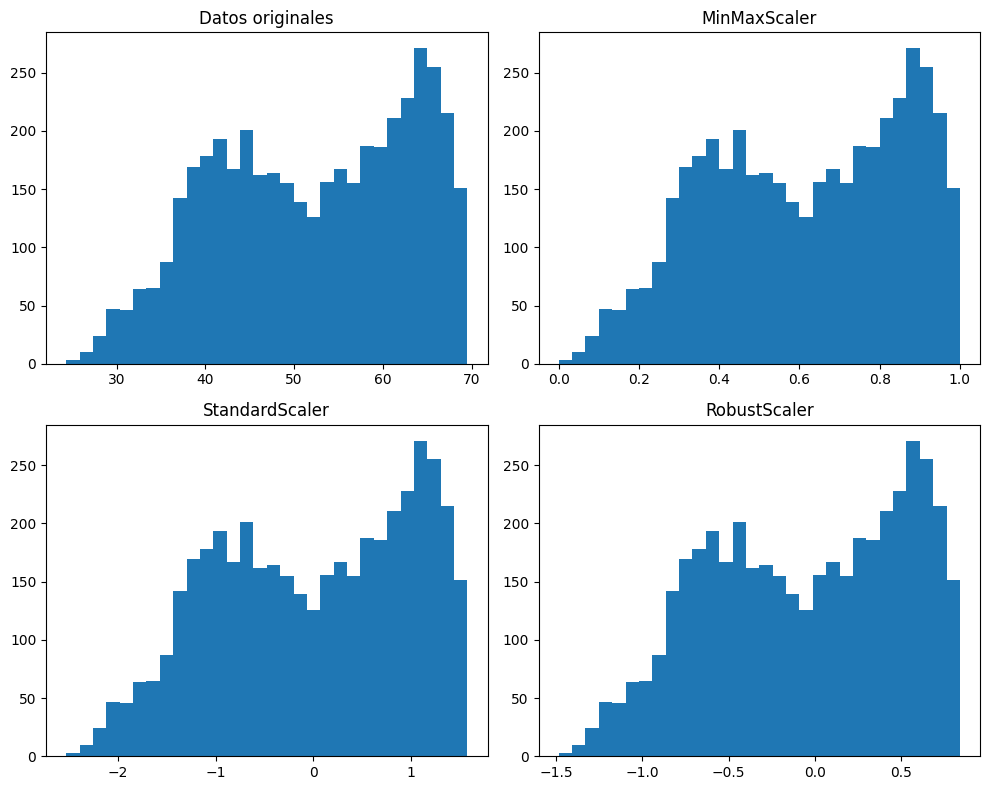

In [ ]:
# Crear figura para comparar como quedaron los escalamientos y normalización

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# Histograma original
axs[0, 0].hist(datos, bins=30)
axs[0, 0].set_title("Datos originales")

# Histograma MinMax
axs[0, 1].hist(datos_min_max, bins=30)
axs[0, 1].set_title("MinMaxScaler")

# Histograma StandardScaler
axs[1, 0].hist(datos_estandar, bins=30)
axs[1, 0].set_title("StandardScaler")

# Histograma RobustScaler
axs[1, 1].hist(datos_robust, bins=30)
axs[1, 1].set_title("RobustScaler")

plt.tight_layout() # Ajustar espacios
plt.show() # Mostrar figura

**Interpretación**

Los métodos de escalamiento modifican la escala de los datos, pero no cambian la forma general de la distribución.

Por eso, los histogramas mantienen una estructura similar antes y después del escalamiento.

# 5 - Guardando el dataset preprocesado y limpio

In [ ]:
# Guardar DataFrame como archivo CSV en la misma carpeta de Drive

dh_df.to_csv("/content/drive/MyDrive/DIMIN/DIMIN2026/DiploModelamientoDatos/Módulo1/Jupyter/dh_df_limpio.csv", index=False)
# evita guardar el índice de Pandas como una columna extra

### <font color='green'>**Extra: Estilos para Python**</font>


Python posee un Programa de Mejoras llamado **PEP** (Python Enhancement program). El [PEP-8](http://recursospython.com/pep8es.pdf) (muy famoso) define convenciones sobre **cómo escribir código Python de forma legible y consistente**

Esto es útil para entender lo que uno hace y sumamente valorado al compartir código con otras personas.

### <font color='green'>**Extra: Recursos para Pandas**</font>

Para obtener más información sobre **Pandas**, se recomiendan los siguientes cursos y tutoriales:

* <a href="http://pandas.pydata.org/">**Documentación en línea de Pandas**</a>: esta es la fuente de referencia para la documentación completa del paquete. Si bien los ejemplos en la documentación tienden a ser pequeños conjuntos de datos generados, la descripción de las opciones es completa y, en general, muy útil para comprender el uso de varias funciones.

* <a href="https://wesmckinney.com/book/">**Python for Data Analysis**</a> escrito por **Wes McKinney** (el creador original de Pandas). Este libro contiene muchos más detalles sobre el paquete Pandas de los que teníamos espacio en este módulo. En particular, se sumerge en profundidad en herramientas para series de tiempo. El libro también tiene muchos ejemplos entretenidos de cómo aplicar Pandas para obtener información a partir de conjuntos de datos del mundo real. Sin embargo, tenga en cuenta que el libro tiene ya varios años y que el paquete Pandas tiene algunas características nuevas que este libro no cubre.

* <a href="http://stackoverflow.com/questions/tagged/pandas">**Stack Overflow**</a>: Pandas tiene tantos usuarios que es probable que cualquier pregunta que tenga se haya formulado y respondido en Stack Overflow. Simplemente vaya a su motor de búsqueda favorito y escriba la pregunta, el problema o el error que ha encontrando; lo más probable es que encuentre su respuesta en una página de Stack Overflow.

* <a href="http://pyvideo.org/search?q=pandas">**Pandas on PyVideo**</a>: desde PyCon hasta SciPy y PyData, muchas conferencias han presentado tutoriales de desarrolladores y usuarios avanzados de Pandas. Los tutoriales de PyCon, en particular, tienden a ser impartidos por presentadores de muy alto nivel.

Usando estos recursos, combinados con el recorrido que se brinda en este módulo, esperamos que esté preparado para usar Pandas para abordar cualquier problema de análisis de datos que encuentre.

### <font color='green'>**Complementos**</font>

* Si quieres ejercitar lo aprendido en Python puedes ir a este [link](https://www.w3schools.com/python/python_exercises.asp)
* Para aprender mas sobre la ciencia de datos y la analitica puedes visitar [este sitio](https://ds-path.netlify.app/sections/ds-path) o bien [este otro](https://virgili0.github.io/Virgilio/).


## <font color='green'>**Extra: Repaso de Python: _Programación Orientada a Objetos_**</font>

En este paradigma de proramación, se crean clases de objetos que comparten una estructura común. Además, cada clase tendrá sus propios métodos (o funciones), atributos, entre otras características. Una clase puede crearse heredando de otra clase y se pueden redefinir sus métodos como agregar otros.

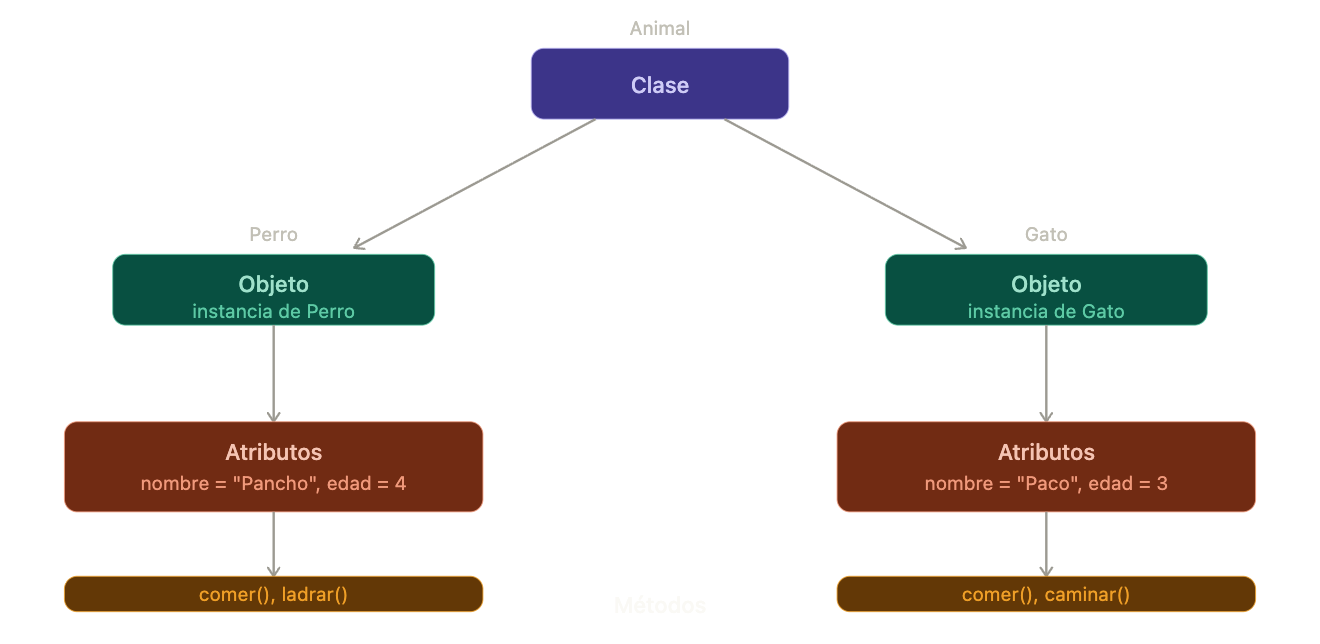

**Beneficios:**
- **Organización**: El código se agrupa en unidades lógicas (clases) más fáciles de entender.
- **Reutilización**: Una clase definida una vez puede usarse múltiples veces.
- **Mantenimiento**: Modificar una clase no afecta al resto del código.

**Riesgos:**
- **Complejidad inicial**: Requiere más planificación antes de escribir el código.
- **Curva de aprendizaje**: No es tan fácil adaptarse al inicio.